# LLM-based TTS: GPT-2 for Audio Token Generation

Pipeline:
1. Dataset preparation (LJSpeech)
2. Audio encoding via FocalCodec
3. Precomputing features (BPE for text, Focal tokens for audio)
4. Training GPT-2 as a Causal Language Model for TTS
5. Inference and evaluation

## 1. Imports & Config

In [1]:
import os, random, warnings, gc, time
import pandas as pd
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import torchaudio
import librosa, soundfile as sf
import pytorch_lightning as pl
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import GPT2Config, GPT2LMHeadModel
from focalcodec import FocalCodec
from phonemizer import phonemize
from dataclasses import dataclass

warnings.filterwarnings("ignore")
torch.set_float32_matmul_precision('high')

# training config
DROPOUT = 0.2
DECAY = 0.05
BATCH_SIZE = 16
NUM_WORKERS = 4
LR = 1e-4
MAX_TOTAL_LEN = 1024

# inference config
GLOBAL_NGRAM_SIZE = 0
GLOBAL_REP_PENALTY = 1.1
GLOBAL_REP_WINDOW = 50

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# data paths
ROOT_DIR = "/home/user/ml_projects/datasets/"
os.makedirs(ROOT_DIR, exist_ok=True)

# cached preprocessing outputs
PHONEME_TOKENS_PATH = "./phoneme_tokens.pt"
AUDIO_LENGTHS_PATH = "./audio_lengths.npy"

# model config
@dataclass
class GPT2TTSConfig:
    base_model: str = "gpt2"
    codebook_size: int = 8192
    n_special_tokens: int = 2
    @property
    def audio_vocab_size(self) -> int: return self.codebook_size + self.n_special_tokens
    @property
    def bos_id(self) -> int: return self.codebook_size
    @property
    def eos_id(self) -> int: return self.codebook_size + 1

# environment info
print(f"PyTorch        : {torch.__version__}")
print(f"Device         : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")

/home/user/.venvs/ml_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch        : 2.5.1+cu121
Device         : cuda
GPU            : NVIDIA GeForce RTX 3060 Ti


## 2. Dataset Loading


Total samples: 13100
Waveform shape: torch.Size([1, 212893]) | SR: 22050
Sample text (normalized): Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition
Sample text (original): Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition
Train: 10480 | Val: 2620


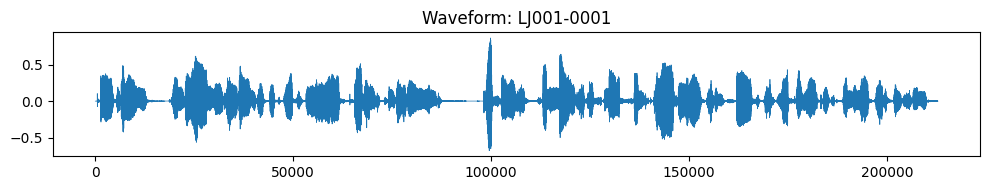

Listen to the audio:


In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Audio, display

# load dataset
ljspeech_dataset = torchaudio.datasets.LJSPEECH(root=ROOT_DIR, download=True)
waveform, sample_rate, transcript, normalized_transcript = ljspeech_dataset[0]

# dataset info
print(f"Total samples: {len(ljspeech_dataset)}")
print(f"Waveform shape: {waveform.shape} | SR: {sample_rate}")
print(f"Sample text (normalized): {normalized_transcript}")
print(f"Sample text (original): {transcript}")

# metadata
meta_path = Path(ROOT_DIR) / 'LJSpeech-1.1' / 'metadata.csv'
meta = pd.read_csv(meta_path, sep='|', header=None, names=['id', 'text', 'text_norm'])
meta['text_norm'] = meta['text_norm'].fillna(meta['text'])
meta['filepath'] = meta['id'].apply(lambda s: f'{ROOT_DIR}/LJSpeech-1.1/wavs/{s}.wav')

# train/val split
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(meta))
split_at = int(0.8 * len(meta))

train_df = meta.iloc[perm[:split_at]].reset_index(drop=True)
val_df   = meta.iloc[perm[split_at:]].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")

# waveform visualization
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(waveform[0].numpy(), linewidth=0.5)
ax.set_title(f"Waveform: {meta['id'][0]}")
plt.tight_layout()
plt.show()

# audio playback
print("Listen to the audio:")
display(Audio(waveform.numpy(), rate=sample_rate))

## 3. Audio Codec

Loading FocalCodec...


Codec Codebook: 8192 | SR In/Out: 16000/16000
Original duration: 2.34s -> 58 tokens


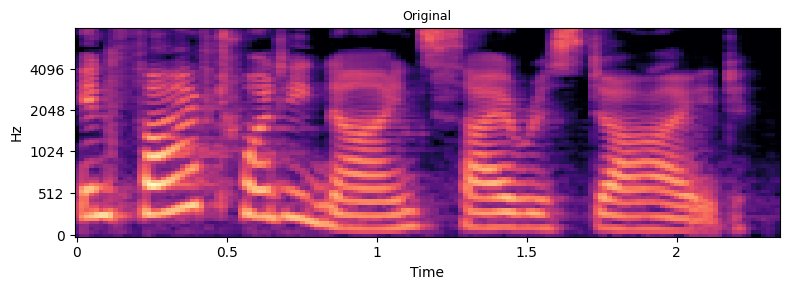

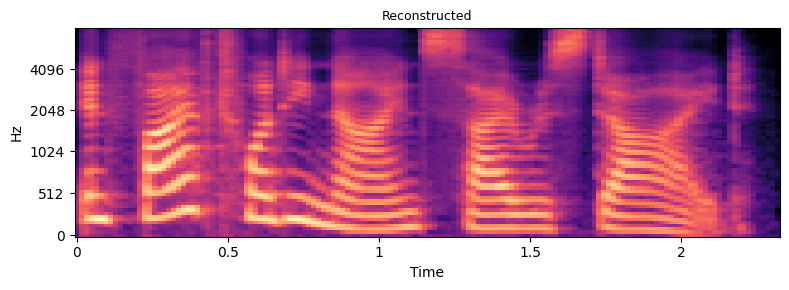

In [3]:
print("Loading FocalCodec...")

# load pretrained codec
codec = FocalCodec.from_pretrained('lucadellalib/focalcodec_25hz').to(DEVICE).eval()

# freeze codec
for p in codec.parameters():
    p.requires_grad_(False)

# codec parameters
CODEBOOK_SIZE = int(codec.codebook.shape[0])
CODEC_SR = codec.sample_rate_input

print(f"Codec Codebook: {CODEBOOK_SIZE} | SR In/Out: {CODEC_SR}/{codec.sample_rate_output}")

# load and normalize wav
def load_wav_16k(path):
    arr, sr = sf.read(path, dtype='float32', always_2d=False)
    if arr.ndim > 1:
        arr = arr.mean(-1)

    wav = torch.from_numpy(arr)
    wav = wav / (wav.abs().max() + 1e-6)

    if sr != CODEC_SR:
        wav = torchaudio.functional.resample(wav, sr, CODEC_SR)

    return wav

# mel spectrogram visualization
def plot_mel(wav, sr, title=''):
    wav = np.asarray(wav).astype(np.float32)
    if wav.ndim > 1:
        wav = wav.mean(0)

    S = librosa.feature.melspectrogram(
        y=wav,
        sr=sr,
        n_fft=1024,
        hop_length=256,
        n_mels=80,
        fmin=50,
        fmax=sr // 2
    )

    fig, ax = plt.subplots(figsize=(8, 3))
    librosa.display.specshow(
        librosa.power_to_db(S, ref=np.max),
        sr=sr,
        hop_length=256,
        x_axis='time',
        y_axis='mel',
        ax=ax
    )

    ax.set_title(title, fontsize=9)
    plt.tight_layout()
    plt.show()

# codec round-trip check
row = val_df.iloc[0]
wav = load_wav_16k(row['filepath']).to(DEVICE)

with torch.no_grad():
    toks = codec.sig_to_toks(wav.unsqueeze(0))
    rec = codec.toks_to_sig(toks).squeeze(0).detach().cpu().numpy()

print(f"Original duration: {wav.shape[-1]/CODEC_SR:.2f}s -> {toks.shape[-1]} tokens")

plot_mel(wav.cpu().numpy(), CODEC_SR, "Original")
plot_mel(rec, codec.sample_rate_output, "Reconstructed")

## 4. Precompute Features

In [4]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from phonemizer.backend import EspeakBackend

# cache file
PRECOMPUTED_FILE = "./precomputed_data.pt"

# IPA normalization
def normalize_ipa(ipa: str) -> str:
    return (
        ipa
        .replace("ᵻ", "ə")
        .replace("ɪ", "I")
        .replace("ʊ", "U")
        .replace("ɔ", "O")
        .replace("ɜ", "E")
        .replace("ː", "")
        .replace("̩", "")
    )

# phoneme tokenizer
class PhonemeTokenizer:
    def __init__(self, language='en-us'):
        self.backend = EspeakBackend(
            language,
            preserve_punctuation=False,
            with_stress=True
        )

        self.special_tokens = ["<pad>", "<unk>", "<bos>", "<eos>"]
        self.vocab = set()
        self.token_to_id = {}
        self.id_to_token = {}

    # build vocab from texts
    def build_vocab(self, texts):
        for text in texts:
            ipa = self.backend.phonemize([text], strip=True)[0]
            ipa = normalize_ipa(ipa)

            for ch in ipa:
                self.vocab.add(ch)

        chars = sorted(list(self.vocab - set(self.special_tokens)))
        all_tokens = self.special_tokens + chars

        self.token_to_id = {t: i for i, t in enumerate(all_tokens)}
        self.id_to_token = {i: t for t, i in self.token_to_id.items()}

    # encode text → ids
    def encode(self, text):
        ipa = self.backend.phonemize([text], strip=True)[0]
        ipa = normalize_ipa(ipa)

        tokens = ["<bos>"]
        for ch in ipa:
            tokens.append(ch if ch in self.token_to_id else "<unk>")
        tokens.append("<eos>")

        return [self.token_to_id[t] for t in tokens]

    # decode ids → text
    def decode(self, ids):
        return "".join([self.id_to_token.get(i, "") for i in ids])


tokenizer = PhonemeTokenizer()

# dataset processing
if os.path.exists(PRECOMPUTED_FILE):
    print(f"Loading cache {PRECOMPUTED_FILE}")
    dataset_cache = torch.load(PRECOMPUTED_FILE)

    train_items = dataset_cache["train"]
    val_items = dataset_cache["val"]

    TEXT_MAX_LEN = dataset_cache["text_max_len"]
    AUDIO_MAX_LEN = dataset_cache["audio_max_len"]

    # restore tokenizer
    tokenizer.token_to_id = dataset_cache["token_to_id"]
    tokenizer.id_to_token = dataset_cache["id_to_token"]

else:
    print("Building dataset...")

    # build vocab
    tokenizer.build_vocab(train_df["text_norm"].tolist())

    def process_split(df, split_name):
        items = []
        text_lens = []
        audio_lens = []

        for _, row in tqdm(df.iterrows(), total=len(df), desc=split_name):

            # text → IPA ids
            text_ids = tokenizer.encode(row["text_norm"])

            # audio → codec tokens
            wav = load_wav_16k(row["filepath"]).to(DEVICE)

            with torch.no_grad():
                audio_toks = codec.sig_to_toks(wav.unsqueeze(0))[0].cpu()

            items.append({
                "id": row["id"],
                "text_ids": torch.tensor(text_ids, dtype=torch.long),
                "audio_ids": audio_toks.long()
            })

            text_lens.append(len(text_ids))
            audio_lens.append(audio_toks.shape[-1])

        return items, text_lens, audio_lens

    train_items, train_tl, train_al = process_split(train_df, "Train")
    val_items, val_tl, val_al = process_split(val_df, "Val")

    TEXT_MAX_LEN = max(max(train_tl), max(val_tl))
    AUDIO_MAX_LEN = max(max(train_al), max(val_al))

    # save cache
    dataset_cache = {
        "train": train_items,
        "val": val_items,
        "text_max_len": TEXT_MAX_LEN,
        "audio_max_len": AUDIO_MAX_LEN,
        "text_vocab_size": len(tokenizer.token_to_id),
        "token_to_id": tokenizer.token_to_id,
        "id_to_token": tokenizer.id_to_token
    }

    torch.save(dataset_cache, PRECOMPUTED_FILE)

# debug info
print(f"Train: {len(train_items)} | Val: {len(val_items)}")
print(f"Vocab size: {len(tokenizer.token_to_id)}")
print(f"TEXT_MAX_LEN: {TEXT_MAX_LEN}")
print(f"AUDIO_MAX_LEN: {AUDIO_MAX_LEN}")



Loading cache ./precomputed_data.pt
Train: 10480 | Val: 2620
Vocab size: 49
TEXT_MAX_LEN: 314
AUDIO_MAX_LEN: 252


## 5. Dataset & DataLoader

In [5]:
# dataset with length filtering
class TokenizedLJSpeech(Dataset):
    def __init__(self, items, max_total_len=1024):
        self.items = [
            it for it in items
            if it["text_ids"].numel() + it["audio_ids"].numel() + 2 <= max_total_len
        ]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]

# batch collation
def tts_collate_fn(batch):
    text_list = [it["text_ids"] for it in batch]
    audio_list = [it["audio_ids"] for it in batch]

    text_lens = torch.tensor([len(t) for t in text_list], dtype=torch.long)
    audio_lens = torch.tensor([len(a) for a in audio_list], dtype=torch.long)

    text_padded = pad_sequence(text_list, batch_first=True, padding_value=0)
    audio_padded = pad_sequence(audio_list, batch_first=True, padding_value=0)

    return {
        "text_ids": text_padded,
        "text_lens": text_lens,
        "audio_ids": audio_padded,
        "audio_lens": audio_lens
    }

# datasets
train_ds = TokenizedLJSpeech(train_items, max_total_len=MAX_TOTAL_LEN)
val_ds   = TokenizedLJSpeech(val_items, max_total_len=MAX_TOTAL_LEN)

print(f"Train dataset size after filtering: {len(train_ds)}")
print(f"Val dataset size after filtering: {len(val_ds)}")

# dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=tts_collate_fn,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=tts_collate_fn,
    num_workers=NUM_WORKERS
)

Train dataset size after filtering: 10480
Val dataset size after filtering: 2620


## 6. TTS Model Definition


In [6]:
import torch
import torch.nn.functional as F

class LogitsProcessor:
    def __init__(self, config):
        self.config = config

    def __call__(self, logits, generated_tokens):
        # 1. Repetition Penalty (Штраф за повтори)
        if self.config.repetition_penalty != 1.0 and generated_tokens:
            logits = self._apply_repetition_penalty(
                logits, 
                generated_tokens, 
                self.config.repetition_penalty, 
                self.config.rep_window
            )

        # 2. No N-gram Blocking (Блокування повторюваних послідовностей)
        if self.config.ngram_size > 0 and len(generated_tokens) >= self.config.ngram_size:
            logits = self._apply_ngram_blocking(
                logits, 
                generated_tokens, 
                self.config.ngram_size
            )

        # 3. Temperature (Температура)[cite: 1]
        if self.config.temperature != 1.0:
            logits = logits / max(self.config.temperature, 1e-5)

        # 4. Min-P Sampling (Відносне відсікання)
        if hasattr(self.config, 'method') and self.config.method == "min_p":
            logits = self._min_p_filter(logits, self.config.min_p_threshold)

        # 5. Nucleus Sampling (Top-P)[cite: 1]
        if self.config.top_p < 1.0:
            logits = self._top_p_filter(logits, self.config.top_p)

        # 6. Top-K Filter[cite: 1]
        if self.config.top_k > 0:
            logits = self._top_k_filter(logits, self.config.top_k)
            
        return logits

    def _apply_repetition_penalty(self, logits, generated_tokens, penalty, window):
        # Визначаємо вікно перегляду[cite: 1]
        win = generated_tokens[-window:] if window > 0 else generated_tokens
        prev = torch.tensor(list(set(win)), device=logits.device)
        
        # Отримуємо логіти для токенів, що вже зустрічалися[cite: 1]
        l_prev = logits.gather(1, prev.unsqueeze(0))
        
        # Якщо логіт позитивний — ділимо, якщо негативний — множимо[cite: 1]
        l_prev = torch.where(l_prev > 0, l_prev / penalty, l_prev * penalty)
        logits.scatter_(1, prev.unsqueeze(0), l_prev)
        return logits

    def _apply_ngram_blocking(self, logits, generated_tokens, ngram_size):
        last_ngram = generated_tokens[-(ngram_size-1):]
        for i in range(len(generated_tokens) - ngram_size + 1):
            if generated_tokens[i : i + ngram_size - 1] == last_ngram:
                forbidden_token = generated_tokens[i + ngram_size - 1]
                logits[:, forbidden_token] = float("-inf") #[cite: 1]
        return logits

    def _min_p_filter(self, logits, threshold):
        probs = F.softmax(logits, dim=-1)
        max_prob = torch.max(probs)
        limit = max_prob * threshold
        logits[probs < limit] = float('-inf')
        return logits

    def _top_p_filter(self, logits, top_p):
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

        # Видаляємо токени з кумулятивною ймовірністю вище порога[cite: 1]
        sorted_indices_to_remove = cumulative_probs > top_p
        # Зсуваємо маску вправо, щоб залишити перший токен, який перевищив поріг[cite: 1]
        sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
        sorted_indices_to_remove[..., 0] = 0

        indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
        logits[indices_to_remove] = float('-inf')
        return logits

    def _top_k_filter(self, logits, k):
        v, _ = torch.topk(logits, min(k, logits.size(-1)))
        logits[logits < v[:, [-1]]] = float('-inf') #[cite: 1]
        return logits

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2Config, GPT2Model

class GPT2TTS(nn.Module):
    def __init__(self, cfg, text_vocab_size: int = 50000):
        super().__init__()
        self.cfg = cfg
        config = GPT2Config(
            n_layer=6, n_head=6, n_embd=384,
            resid_pdrop=0.2, embd_pdrop=0.2, attn_pdrop=0.2,
            vocab_size=text_vocab_size
        )
        self.base = GPT2Model(config)
        H, V = config.n_embd, cfg.audio_vocab_size
        self.audio_emb = nn.Embedding(V, H)
        self.audio_head = nn.Linear(H, V, bias=False)
        self.audio_head.weight = self.audio_emb.weight
        nn.init.normal_(self.audio_emb.weight, std=0.02)

    def _build_inputs(self, text_ids, text_lens, audio_ids, audio_lens, drop_prob=0.15):
        B, device = text_ids.size(0), text_ids.device
        L_max = int(torch.max(text_lens + audio_lens + 2).item())
        inputs = torch.zeros(B, L_max, self.base.config.n_embd, device=device)
        mask = torch.zeros(B, L_max, device=device, dtype=torch.long)
        labels = torch.full((B, L_max), -100, device=device, dtype=torch.long)

        if self.training and drop_prob > 0:
            keep = torch.rand(B, device=device) > drop_prob
            text_ids = text_ids * keep.unsqueeze(1).long()

        text_emb = self.base.wte(text_ids)
        audio_emb = self.audio_emb(audio_ids)
        bos_e, eos_e = self.audio_emb.weight[self.cfg.bos_id], self.audio_emb.weight[self.cfg.eos_id]

        for i in range(B):
            tl, al = text_lens[i].item(), audio_lens[i].item()
            inputs[i, :tl], mask[i, :tl] = text_emb[i, :tl], 1
            inputs[i, tl], mask[i, tl] = bos_e, 1
            if al > 0:
                inputs[i, tl+1 : tl+1+al], mask[i, tl+1 : tl+1+al] = audio_emb[i, :al], 1
                labels[i, tl+1 : tl+1+al] = audio_ids[i, :al]
            inputs[i, tl+1+al], mask[i, tl+1+al], labels[i, tl+1+al] = eos_e, 1, self.cfg.eos_id
        return inputs, mask, labels

    def forward(self, text_ids, text_lens, audio_ids, audio_lens):
        inputs, mask, labels = self._build_inputs(text_ids, text_lens, audio_ids, audio_lens)
        h = self.base(inputs_embeds=inputs, attention_mask=mask).last_hidden_state
        logits = self.audio_head(h)
        loss = F.cross_entropy(logits[:, :-1].reshape(-1, self.cfg.audio_vocab_size), 
                               labels[:, 1:].reshape(-1), ignore_index=-100, label_smoothing=0.01)
        return {"loss": loss, "logits": logits}

    def _contrastive_selection(self, logits, current_h, h_history, config):
        """Реалізація Contrastive Search на рівні моделі"""
        if not h_history:
            return torch.argmax(logits, dim=-1).item()

        # 1. Беремо Top-K кандидатів
        top_logits, top_indices = torch.topk(logits, config.top_k)
        
        # 2. Обчислюємо штраф за схожість з історією
        history_tensor = torch.stack(h_history) # [steps, hidden_dim]
        # Similarity між поточним вектором та всіма векторами в історії
        similarity = F.cosine_similarity(current_h.unsqueeze(0), history_tensor, dim=-1)
        l_penalty = torch.max(similarity)

        # 3. Підрахунок фінальних балів: (1-alpha)*Prob - alpha*MaxSimilarity
        probs = F.softmax(top_logits, dim=-1)
        scores = (1 - config.alpha) * probs - config.alpha * l_penalty
        
        best_idx = torch.argmax(scores)
        return top_indices[0, best_idx].item()

    @torch.no_grad()
    def generate_audio(self, text_ids, config, processor):
        """Універсальний цикл генерації"""
        self.eval()
        device = text_ids.device
        
        prefix_emb = torch.cat([
            self.base.wte(text_ids).unsqueeze(0), 
            self.audio_emb.weight[self.cfg.bos_id].view(1, 1, -1)
        ], dim=1)
        mask = torch.ones(1, prefix_emb.size(1), device=device, dtype=torch.long)
        
        out = self.base(inputs_embeds=prefix_emb, attention_mask=mask, use_cache=True)
        past, h = out.past_key_values, out.last_hidden_state[:, -1, :]
        
        generated = []
        h_history = [] 

        for _ in range(config.max_new_tokens):
            logits = self.audio_head(h) 
            
            if hasattr(config, 'method') and config.method == "contrastive":
                next_tok_id = self._contrastive_selection(logits, h, h_history, config)
                h_history.append(h.squeeze(0))
                next_tok = torch.tensor([[next_tok_id]], device=device)
            else:
                # Використовуємо зовнішній LogitsProcessor[cite: 1]
                processed_logits = processor(logits, generated)
                
                if not getattr(config, 'do_sample', True):
                    next_tok = torch.argmax(processed_logits, dim=-1).unsqueeze(-1)
                else:
                    probs = F.softmax(processed_logits, dim=-1)
                    next_tok = torch.multinomial(probs, num_samples=1)

            if next_tok.item() == self.cfg.eos_id:
                break
            generated.append(next_tok.item())

            mask = torch.cat([mask, torch.ones(1, 1, device=device)], dim=1)
            out = self.base(
                inputs_embeds=self.audio_emb(next_tok), 
                attention_mask=mask, 
                past_key_values=past, 
                use_cache=True
            )
            past, h = out.past_key_values, out.last_hidden_state[:, -1, :]

        return torch.tensor(generated, dtype=torch.long, device=device)

## 7. Training with PyTorch Lightning

In [9]:
from transformers import get_cosine_schedule_with_warmup
import pytorch_lightning as pl
import torch

class GPT2TTSLightning(pl.LightningModule):
    def __init__(self, model, lr=1e-4): 
        super().__init__()
        self.model = model
        self.lr = lr

    def training_step(self, batch, batch_idx):
        loss = self.model(**batch)["loss"]
        self.log("train_loss_epoch", loss, on_epoch=True, prog_bar=False)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self.model(**batch)["loss"]
        self.log("val_loss", loss, prog_bar=True, on_epoch=True)
        return loss

    def generate(self, text_ids, config):
        """Точка входу для генерації з різними стратегіями[cite: 1]"""
        # Якщо обрано Beam Search, використовуємо вбудований метод HuggingFace
        if hasattr(config, 'method') and config.method == "beam":
            # Для Beam Search через transformers потрібно підготувати inputs_embeds
            # Це спрощений варіант, який працює, якщо модель правильно налаштована
            return self.model.base.generate(
                inputs_embeds=self.model.base.wte(text_ids).unsqueeze(0),
                num_beams=getattr(config, 'num_beams', 4),
                max_length=config.max_new_tokens,
                eos_token_id=self.model.cfg.eos_id,
                pad_token_id=0
            )
        
        # Для всіх інших методів використовуємо наш кастомний цикл
        processor = LogitsProcessor(config)
        return self.model.generate_audio(text_ids, config, processor)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=0.05)
        total_steps = self.trainer.estimated_stepping_batches
        scheduler = get_cosine_schedule_with_warmup(
            optimizer, num_warmup_steps=int(0.05 * total_steps), num_training_steps=total_steps
        )
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "interval": "step"}}
    def __init__(self, model, lr=LR): 
        super().__init__()
        self.model = model
        self.lr = lr
        
        self.drop_prob = 0.15 

    def training_step(self, batch, batch_idx):
        loss = self.model(**batch)["loss"]
        
        self.log("train_loss_epoch", loss, on_epoch=True, prog_bar=False)
        if batch_idx % 200 == 0:
            print(f"Step {batch_idx}, loss = {loss.item():.4f}")
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self.model(**batch)["loss"]
        self.log("val_loss", loss, prog_bar=True, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        train_loss_epoch = self.trainer.callback_metrics.get("train_loss_epoch")
        val_loss = self.trainer.callback_metrics.get("val_loss")
        if train_loss_epoch is not None and val_loss is not None:
            print(f"Epoch {self.current_epoch} | train_loss = {train_loss_epoch:.4f}, val_loss = {val_loss:.4f}")
        elif val_loss is not None:
            print(f"Epoch {self.current_epoch} finished | val_loss = {val_loss:.4f}")
        else:
            print(f"Epoch {self.current_epoch} finished")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=DECAY)
        
        total_steps = self.trainer.estimated_stepping_batches
        warmup_steps = int(0.05 * total_steps)
        scheduler = get_cosine_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
            }
        }

    @classmethod
    def from_ckpt(cls, ckpt_path, cfg, text_vocab_size, lr=LR):
        model = GPT2TTS(cfg, text_vocab_size=text_vocab_size)

        lm = cls.load_from_checkpoint(
            ckpt_path,
            model=model,
            lr=lr,
            strict=True
        )
        return lm

## 8. Training

In [ ]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Callback
from pathlib import Path
import pytorch_lightning as pl
import torch
import gc

# paths
SAVE_DIR = Path("./tts_checkpoints")
SAVE_DIR.mkdir(exist_ok=True)

# callbacks
checkpoint_cb = ModelCheckpoint(
    dirpath=str(SAVE_DIR),
    filename="gpt2-tts-{epoch:02d}-{val_loss:.4f}",
    monitor="val_loss",
    mode="min",
    save_top_k=3,
    save_last=True,
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=15,
    mode="min",
    verbose=True
)

class MemoryCallback(Callback):
    """Free memory between epochs."""
    def _clear(self):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

    def on_train_epoch_end(self, trainer, pl_module):
        self._clear()

    def on_validation_epoch_end(self, trainer, pl_module):
        self._clear()

memory_cb = MemoryCallback()

# model (from scratch)
cfg = GPT2TTSConfig()
vocab_size = len(tokenizer.token_to_id)

base_model = GPT2TTS(cfg, text_vocab_size=vocab_size)
lightning_model = GPT2TTSLightning(model=base_model)

# enable CFG-style dropout if needed
lightning_model.drop_prob = 0.15

# trainer
trainer = pl.Trainer(
    max_epochs=50,
    accelerator="gpu",
    devices=1,
    precision="bf16-mixed",
    callbacks=[checkpoint_cb, early_stop_cb, memory_cb],
    gradient_clip_val=1.0,
    num_sanity_val_steps=0,
    log_every_n_steps=100,
)

# pre-run cleanup
gc.collect()
torch.cuda.empty_cache()

print("[INFO] Training from scratch started")

trainer.fit(
    model=lightning_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

log_path = "/home/user/ml_projects/workspace/audioML/lab4/lightning_logs/version_33/events.out.tfevents.1777677353.cachyos-x8664.63542.0"

def plot_lightning_logs(path):
    event_acc = EventAccumulator(path)
    event_acc.Reload()

    tags = event_acc.Tags()["scalars"]
    print(f"[INFO] scalars: {tags}")

    def extract(tag):
        return pd.DataFrame(
            [(e.step, e.value) for e in event_acc.Scalars(tag)],
            columns=["step", tag]
        )

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 5))

    # train loss (step-level)
    if "train_loss_epoch_step" in tags:
        df = extract("train_loss_epoch_step")
        plt.plot(df["step"], df["train_loss_epoch_step"], label="train_step", alpha=0.7)

    # train loss (epoch-level)
    if "train_loss_epoch_epoch" in tags:
        df = extract("train_loss_epoch_epoch")
        plt.plot(df["step"], df["train_loss_epoch_epoch"], label="train_epoch", linewidth=2)

    # validation loss
    if "val_loss" in tags:
        df = extract("val_loss")
        plt.plot(df["step"], df["val_loss"], label="val", linewidth=2)

    plt.title("Training curves")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_lightning_logs(log_path)

## 9. Inference

In [10]:
from dataclasses import dataclass

@dataclass
class GenerationConfig:
    method: str = "sampling"  # "greedy", "sampling", "min_p", "contrastive", "beam"
    max_new_tokens: int = 400
    temperature: float = 0.75
    top_k: int = 50
    top_p: float = 0.9
    min_p_threshold: float = 0.1
    alpha: float = 0.6  # Для Contrastive Search
    repetition_penalty: float = 1.1
    rep_window: int = 50
    ngram_size: int = 0
    do_sample: bool = True
    num_beams: int = 4

In [11]:
import torch
import torchaudio


# inference wrappers

class TTSInferencer:
    def __init__(self, ckpt_path, cfg, vocab_size):
        print(f"[LOAD] model checkpoint: {ckpt_path}")
        # Використовуємо наш Lightning враппер для завантаження
        self.lightning_module = GPT2TTSLightning.from_ckpt(
            ckpt_path, cfg, vocab_size
        ).to(DEVICE).eval()
        self.model = self.lightning_module.model

    @torch.no_grad()
    def generate(self, text, config: GenerationConfig):
        # Токенізація тексту
        text_ids = torch.tensor(
            tokenizer.encode(text),
            dtype=torch.long,
            device=DEVICE
        )

        # Викликаємо уніфікований метод генерації з враппера
        audio_toks = self.lightning_module.generate(text_ids, config)

        if audio_toks.numel() == 0:
            return None

        # Декодування токенів у аудіосигнал[cite: 1]
        return codec.toks_to_sig(
            audio_toks.unsqueeze(0)
        ).squeeze(0).cpu()

class CFG_TTSInferencer(TTSInferencer):
    @torch.no_grad()
    def generate_cfg(self, text, config: GenerationConfig, guidance_scale=2.5):
        self.model.eval()
        device = next(self.model.parameters()).device
        processor = LogitsProcessor(config)

        text_ids = torch.tensor(tokenizer.encode(text), dtype=torch.long, device=device)
        
        # Створення батчу: [conditioned, unconditioned][cite: 1]
        batch_text = torch.cat([text_ids.unsqueeze(0), torch.zeros_like(text_ids.unsqueeze(0))], dim=0)
        
        bos_emb = self.model.audio_emb.weight[self.model.cfg.bos_id].view(1, 1, -1).expand(2, 1, -1)
        hidden = torch.cat([self.model.base.wte(batch_text), bos_emb], dim=1)

        # Початковий прохід з KV-кешем[cite: 1]
        out = self.model.base(inputs_embeds=hidden, use_cache=True)
        past, h = out.past_key_values, out.last_hidden_state[:, -1, :]
        
        generated = []
        for _ in range(config.max_new_tokens):
            logits = self.model.audio_head(h)
            logits_cond, logits_uncond = logits[0], logits[1]

            # CFG mixing: посилення впливу текстової умови[cite: 1]
            final_logits = logits_uncond + guidance_scale * (logits_cond - logits_uncond)
            final_logits = final_logits.unsqueeze(0) # Додаємо batch dim для процесора

            # Застосовуємо фільтри через процесор ( Penalty, Min-P, Top-K/P)[cite: 1]
            final_logits = processor(final_logits, generated)

            if not config.do_sample:
                next_token = torch.argmax(final_logits, dim=-1)
            else:
                next_token = torch.multinomial(F.softmax(final_logits, dim=-1), 1)

            if next_token.item() == self.model.cfg.eos_id:
                break
            generated.append(next_token.item())

            # Оновлення кешу для наступного кроку[cite: 1]
            next_emb = self.model.audio_emb(next_token.expand(2, 1))
            out = self.model.base(inputs_embeds=next_emb, past_key_values=past, use_cache=True)
            past, h = out.past_key_values, out.last_hidden_state[:, -1, :]

        return codec.toks_to_sig(torch.tensor([generated], device=device)).squeeze(0).cpu()

In [13]:
import IPython.display as ipd

# 1. Спільна конфігурація моделі та словника
model_cfg = GPT2TTSConfig() 
vocab_size = len(tokenizer.token_to_id) 
test_text = "I wanna just run away from here."

# 2. Шляхи до чекпоінтів
baseline_ckpt = "/home/user/ml_projects/workspace/audioML/lab4/tts_checkpoints/gpt2-tts-epoch=44-val_loss=6.1493.ckpt"
cfg_ep17_ckpt = "/home/user/ml_projects/workspace/audioML/lab4/tts_checkpoints/gpt2-tts-epoch=17-val_loss=6.1792.ckpt" 

# 3. Ініціалізація інференсерів
infer_base = TTSInferencer(baseline_ckpt, model_cfg, vocab_size)
infer_cfg17 = CFG_TTSInferencer(cfg_ep17_ckpt, model_cfg, vocab_size)

test_configs = [
    ("Greedy (Deterministic)", infer_base, GenerationConfig(
        method="greedy", do_sample=False, max_new_tokens=400
    )),
    
    ("Min-P Sampling (Robust)", infer_base, GenerationConfig(
        method="min_p", min_p_threshold=0.05, temperature=0.8, do_sample=True
    )),
    
    ("Contrastive Search (No Repetition)", infer_base, GenerationConfig(
        method="contrastive", top_k=5, alpha=0.6, max_new_tokens=400
    )),
    
    ("CFG + Balanced Sampling", infer_cfg17, GenerationConfig(
        method="sampling", temperature=0.8, top_k=50, max_new_tokens=400
    )),
]

print(f"Generating samples for: {test_text}\n")

for name, infer, gen_cfg in test_configs:
    print(f"--- {name} ---")
    
    try:
        if isinstance(infer, CFG_TTSInferencer) and name.startswith("CFG"):
            # Для CFG методу використовуємо специфічний виклик
            audio = infer.generate_cfg(test_text, gen_cfg, guidance_scale=2.5)
        else:
            # Уніфікований виклик для всіх інших методів[cite: 1]
            audio = infer.generate(test_text, gen_cfg)
            
        if audio is not None:
            ipd.display(ipd.Audio(audio, rate=16000)) 
        else:
            print("Failed to generate: Empty output.")
            
    except Exception as e:
        print(f"Error during generation with {name}: {e}")

[LOAD] model checkpoint: /home/user/ml_projects/workspace/audioML/lab4/tts_checkpoints/gpt2-tts-epoch=44-val_loss=6.1493.ckpt
[LOAD] model checkpoint: /home/user/ml_projects/workspace/audioML/lab4/tts_checkpoints/gpt2-tts-epoch=17-val_loss=6.1792.ckpt
Generating samples for: I wanna just run away from here.

--- Greedy (Deterministic) ---


--- Min-P Sampling (Robust) ---


--- Contrastive Search (No Repetition) ---


--- CFG + Balanced Sampling ---


In [14]:
import os
import torch
import torchaudio
import gc
import shutil
from pathlib import Path
from tqdm.auto import tqdm

# Використовуємо існуючу конфігурацію словника
model_cfg = GPT2TTSConfig() 
vocab_size = len(tokenizer.token_to_id) 

if 'DEVICE' not in globals():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

FINAL_OUTPUT_DIR = Path("./final_eval_mixed_sampling")
if FINAL_OUTPUT_DIR.exists():
    shutil.rmtree(FINAL_OUTPUT_DIR)
FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Визначаємо набори конфігурацій для різних моделей
# Для Baseline протестуємо класичні та нові методи
BASELINE_CONFIGS = [
    ("greedy",      GenerationConfig(method="greedy", do_sample=False)),
    ("min_p",       GenerationConfig(method="min_p", min_p_threshold=0.05, temperature=0.8)),
    ("contrastive", GenerationConfig(method="contrastive", top_k=5, alpha=0.6)),
    ("balanced",    GenerationConfig(method="sampling", temperature=0.8, top_k=50)),
]

# Для CFG зазвичай використовують стабільний Greedy або Balanced
CFG_CONFIGS = [
    ("cfg_greedy",   GenerationConfig(method="greedy", do_sample=False)),
    ("cfg_balanced", GenerationConfig(method="sampling", temperature=0.8, top_k=50)),
]

# 2. Мапа моделей (з новими іменами)
MODELS_TO_RUN = {
    "baseline": {
        "path": "/home/user/ml_projects/workspace/audioML/lab4/tts_checkpoints/gpt2-tts-epoch=44-val_loss=6.1493.ckpt",
        "is_cfg": False,
        "configs": BASELINE_CONFIGS
    },
    "cfg_fine-tune": {
        "path": "/home/user/ml_projects/workspace/audioML/lab4/tts_checkpoints/gpt2-tts-epoch=17-val_loss=6.1792.ckpt",
        "is_cfg": True,
        "configs": CFG_CONFIGS
    }
}

test_texts = [
    "The North Wind and the Sun were disputing which was the stronger, when a traveler came along wrapped in a warm cloak.",
    "He bought apples, oranges, and bananas; however, he forgot the most important thing: milk.",
    "Could you please tell me how to get to the nearest train station? Is it far from here?",
    "The meeting is scheduled for March 15th, 2026, at 10:30 AM in room number 402.",
    "Stop right there! I can't believe you actually did it! That is absolutely amazing!",
    "In a hole in the ground there lived a hobbit, and though it was not a nasty, dirty, wet hole, it was comfortable.",
    "Quantum entanglement is a physical phenomenon that occurs when a group of particles are generated or interact.",
    "Oh. I see. Well, okay then. Yes.",
    "She sells seashells by the seashore. The shells she sells are surely seashells.",
    "The city was quiet, draped in a thin veil of blue mist, waiting for a morning that felt like it would never come."
]

FIXED_SCALE = 2.5
generated_files = []

print(f"[INFO] Starting generation -> {FINAL_OUTPUT_DIR}")

for model_key, m_info in MODELS_TO_RUN.items():
    print(f"\n[PROCESS] Model: {model_key}")

    # Ініціалізуємо відповідний інференсер[cite: 1]
    if m_info["is_cfg"]:
        inferencer = CFG_TTSInferencer(
            ckpt_path=m_info["path"], 
            cfg=model_cfg, 
            vocab_size=vocab_size
        )
    else:
        inferencer = TTSInferencer(
            ckpt_path=m_info["path"], 
            cfg=model_cfg, 
            vocab_size=vocab_size
        )

    for i, text in enumerate(tqdm(test_texts, desc=f"Sentences for {model_key}")):
        for conf_name, gen_cfg in m_info["configs"]:

            if m_info["is_cfg"]:
                # Виклик для CFG моделі[cite: 1]
                wav_tensor = inferencer.generate_cfg(
                    text=text,
                    config=gen_cfg,
                    guidance_scale=FIXED_SCALE
                )
            else:
                # Уніфікований виклик для Baseline[cite: 1]
                wav_tensor = inferencer.generate(
                    text=text,
                    config=gen_cfg
                )

            if wav_tensor is None:
                continue

            # Формуємо ім'я файлу з новими назвами моделей[cite: 1]
            filename = f"{model_key}_text{i}_{conf_name}.wav"
            save_path = FINAL_OUTPUT_DIR / filename

            torchaudio.save(
                str(save_path),
                wav_tensor.unsqueeze(0),
                16000 # Sample rate виходу кодека
            )

            generated_files.append({
                "text": text,
                "filepath": str(save_path),
                "model": model_key,
                "sampling": conf_name,
                "is_cfg": m_info["is_cfg"]
            })

    # Очищення пам'яті після кожної моделі
    del inferencer
    gc.collect()
    torch.cuda.empty_cache()

print("\n" + "="*50)
print(f"[SUCCESS] Total files generated: {len(generated_files)}")
print(f"[LOCATION] {FINAL_OUTPUT_DIR}")

[INFO] Starting generation -> final_eval_mixed_sampling

[PROCESS] Model: baseline
[LOAD] model checkpoint: /home/user/ml_projects/workspace/audioML/lab4/tts_checkpoints/gpt2-tts-epoch=44-val_loss=6.1493.ckpt


Sentences for baseline: 100%|██████████| 10/10 [00:17<00:00,  1.78s/it]



[PROCESS] Model: cfg_fine-tune
[LOAD] model checkpoint: /home/user/ml_projects/workspace/audioML/lab4/tts_checkpoints/gpt2-tts-epoch=17-val_loss=6.1792.ckpt


Sentences for cfg_fine-tune: 100%|██████████| 10/10 [00:08<00:00,  1.20it/s]



[SUCCESS] Total files generated: 60
[LOCATION] final_eval_mixed_sampling


## Evaluation

In [15]:
import os
import pandas as pd
import torch
import torchaudio
import whisper
import jiwer
import warnings
import re
from pathlib import Path
from tqdm.auto import tqdm
from speechbrain.inference.speaker import EncoderClassifier

warnings.filterwarnings("ignore")

# test set
test_texts = [
    "The North Wind and the Sun were disputing which was the stronger, when a traveler came along wrapped in a warm cloak.",
    "He bought apples, oranges, and bananas; however, he forgot the most important thing: milk.",
    "Could you please tell me how to get to the nearest train station? Is it far from here?",
    "The meeting is scheduled for March 15th, 2026, at 10:30 AM in room number 402.",
    "Stop right there! I can't believe you actually did it! That is absolutely amazing!",
    "In a hole in the ground there lived a hobbit, and though it was not a nasty, dirty, wet hole, it was comfortable.",
    "Quantum entanglement is a physical phenomenon that occurs when a group of particles are generated or interact.",
    "Oh. I see. Well, okay then. Yes.",
    "She sells seashells by the seashore. The shells she sells are surely seashells.",
    "The city was quiet, draped in a thin veil of blue mist, waiting for a morning that felt like it would never come."
]

EVAL_DIR = Path("/home/user/ml_projects/workspace/audioML/lab4/final_eval_mixed_sampling/")

# models for evaluation
print("[INFO] loading evaluation models")

asr_model = whisper.load_model("base", device=DEVICE)

utmos_predictor = torch.hub.load(
    "tarepan/SpeechMOS:v1.2.0",
    "utmos22_strong",
    trust_repo=True
).to(DEVICE)
utmos_predictor.eval()

speaker_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    run_opts={"device": DEVICE},
    savedir="./pretrained_models/spkrec-ecapa-voxceleb"
)

# reference speaker embedding
print("[INFO] building speaker reference embedding")

num_reference_files = 10
reference_embeddings = []

reference_paths = train_df.sample(
    n=num_reference_files,
    random_state=SEED
)["filepath"].tolist()

for path in tqdm(reference_paths, desc="reference"):
    wav, sr = torchaudio.load(path)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)

    with torch.no_grad():
        emb = speaker_model.encode_batch(wav.to(DEVICE))
        reference_embeddings.append(emb.squeeze())

stable_ref_embedding = torch.mean(torch.stack(reference_embeddings), dim=0)

# collect generated files
generated_files = []

for wav_path in EVAL_DIR.glob("*.wav"):
    name = wav_path.stem

    text_match = re.search(r"text(\d+)", name)
    if not text_match:
        continue

    idx = int(text_match.group(1))
    model_name = name.split(f"_text{idx}")[0]
    sampling = name.split(f"text{idx}_")[-1]

    generated_files.append({
        "text": test_texts[idx],
        "filepath": str(wav_path),
        "model": model_name,
        "sampling": sampling,
        "scale": 2.5 if "CFG" in model_name else 1.0
    })

# evaluation
results = []

text_transform = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip()
])

print(f"[INFO] evaluating {len(generated_files)} samples")

for item in tqdm(generated_files):
    wav, sr = torchaudio.load(item["filepath"])
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)

    with torch.no_grad():
        utmos_val = utmos_predictor(wav.to(DEVICE), 16000).item()

        gen_emb = speaker_model.encode_batch(wav.to(DEVICE)).squeeze()
        secs_val = torch.nn.functional.cosine_similarity(
            stable_ref_embedding.unsqueeze(0),
            gen_emb.unsqueeze(0)
        ).item()

    transcription = asr_model.transcribe(item["filepath"])["text"]

    cer_val = jiwer.cer(
        text_transform(item["text"]),
        text_transform(transcription)
    ) if transcription else 1.0

    results.append({
        "Model": item["model"],
        "Sampling": item["sampling"],
        "Text": item["text"][:30] + "...",
        "CER": cer_val,
        "UTMOS": utmos_val,
        "SECS": secs_val
    })

# summary
df_full = pd.DataFrame(results)
df_full.to_csv("final_mixed_eval_results_full.csv", index=False)

print("[DONE] summary metrics")

summary = df_full.groupby(["Model", "Sampling"])[
    ["CER", "UTMOS", "SECS"]
].mean().reset_index()

print(summary.to_markdown(index=False))

[INFO] loading evaluation models


Using cache found in /home/user/.cache/torch/hub/tarepan_SpeechMOS_v1.2.0
Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


[INFO] building speaker reference embedding


reference: 100%|██████████| 10/10 [00:00<00:00, 36.35it/s]


[INFO] evaluating 60 samples


100%|██████████| 60/60 [00:14<00:00,  4.26it/s]

[DONE] summary metrics
| Model         | Sampling     |      CER |   UTMOS |     SECS |
|:--------------|:-------------|---------:|--------:|---------:|
| baseline      | balanced     | 0.329516 | 4.21267 | 0.533804 |
| baseline      | contrastive  | 0.281197 | 4.27652 | 0.5713   |
| baseline      | greedy       | 0.281606 | 4.3603  | 0.577627 |
| baseline      | min_p        | 0.28529  | 4.38471 | 0.594845 |
| cfg_fine-tune | cfg_balanced | 0.164786 | 4.17695 | 0.5449   |
| cfg_fine-tune | cfg_greedy   | 0.275528 | 4.13311 | 0.579032 |


## 10. Plots generation

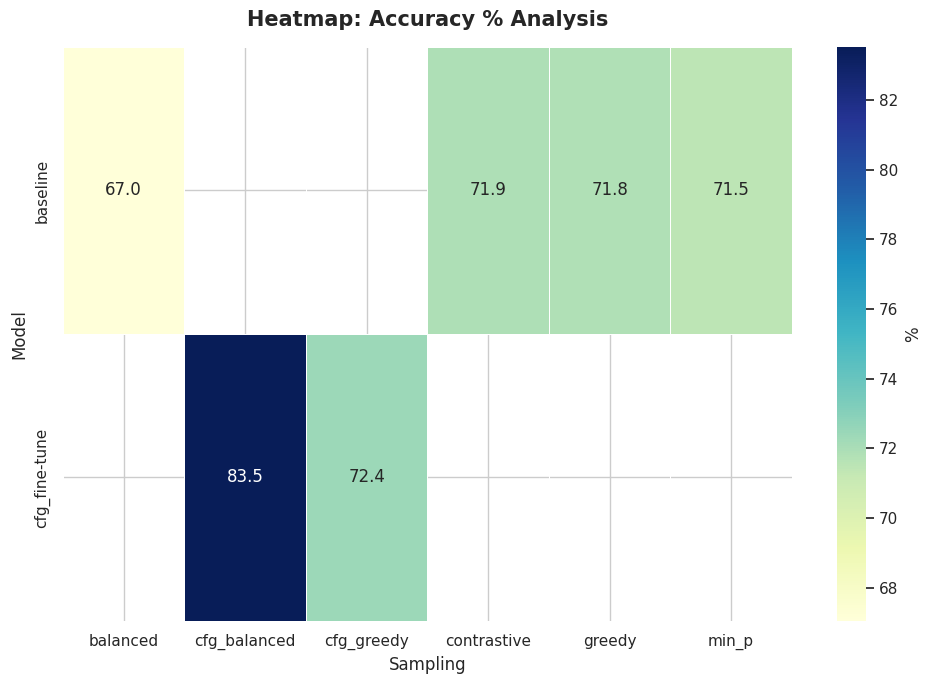

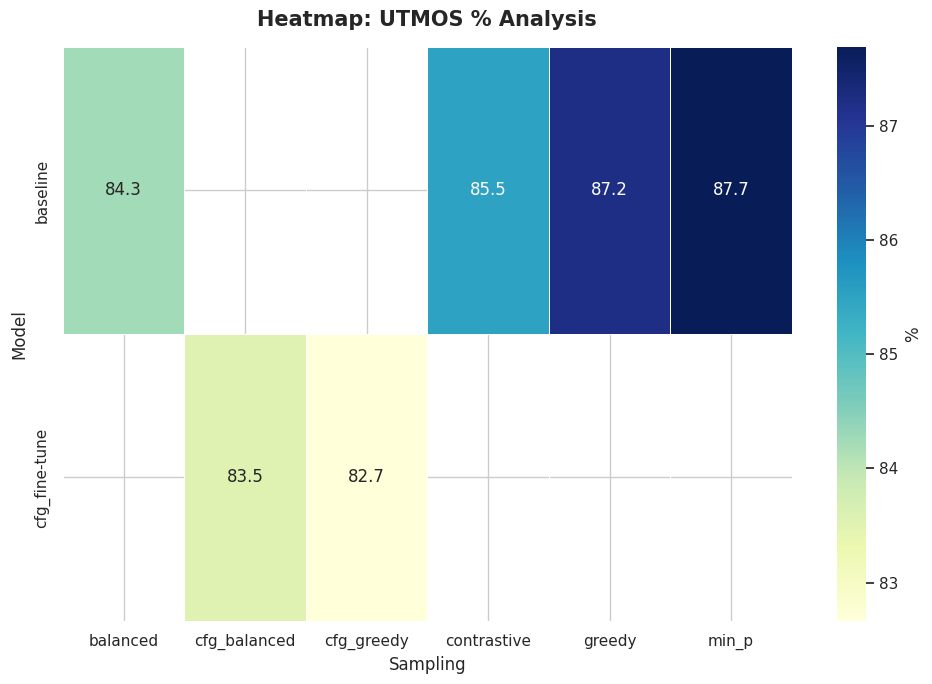

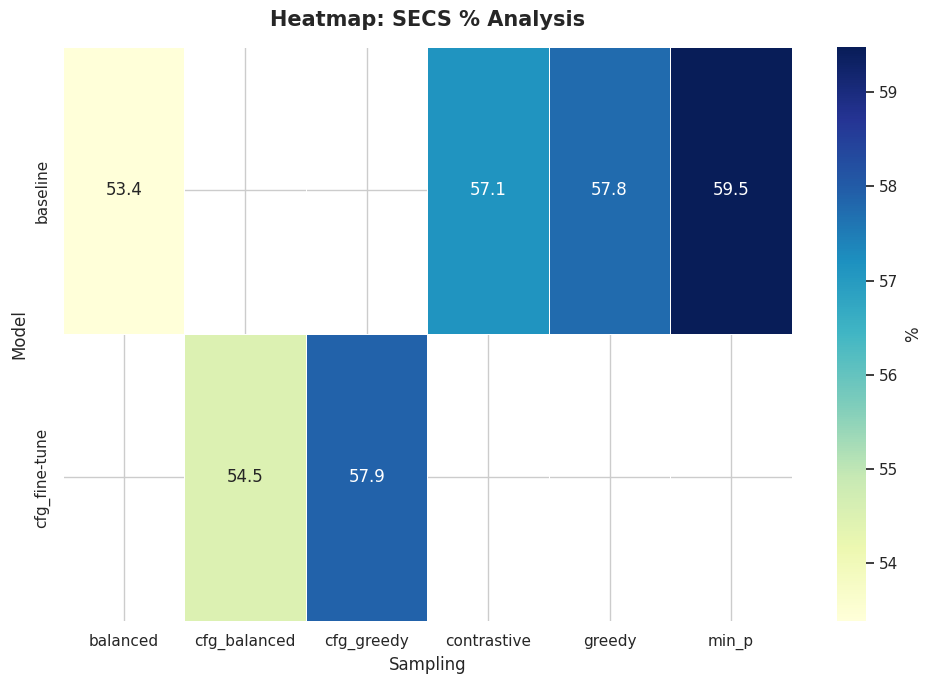

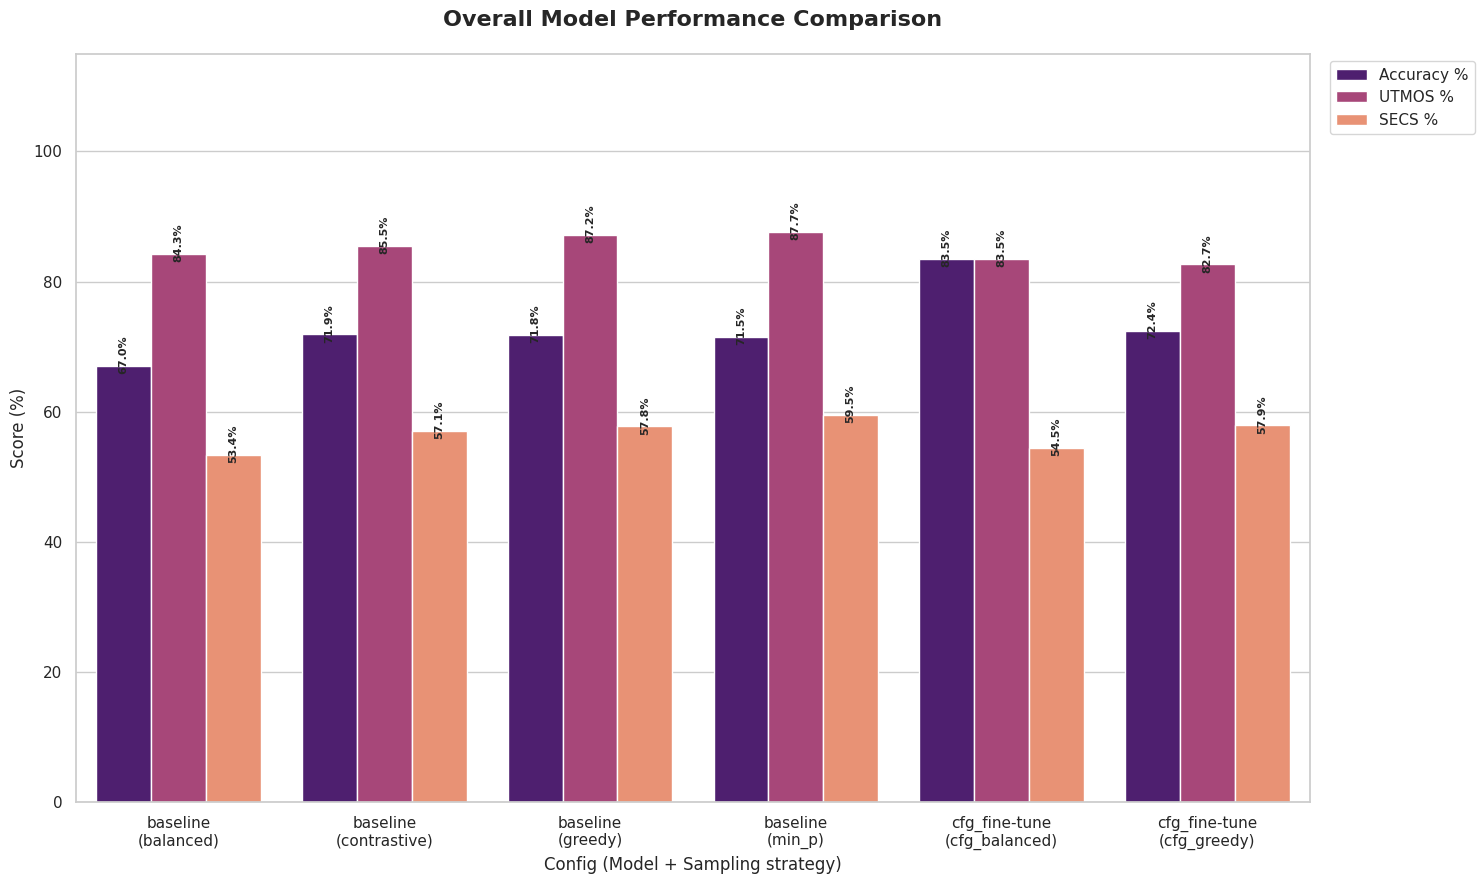

Все 4 полотна сохранены в: plots/individual_slides


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# 1. Загрузка и подготовка данных
df_full = pd.read_csv("final_mixed_eval_results_full.csv")

# Расчет метрик в процентах
df_full["Accuracy %"] = (1 - df_full["CER"]) * 100
df_full["UTMOS %"] = (df_full["UTMOS"] / 5.0) * 100
df_full["SECS %"] = df_full["SECS"] * 100
df_full["Config"] = df_full["Model"] + "\n(" + df_full["Sampling"] + ")"

metrics_cols = ["Accuracy %", "UTMOS %", "SECS %"]
plot_dir = Path("./plots/individual_slides")
plot_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

# --- ПОЛОТНА 1, 2, 3: ХИТМАПЫ (по одному на метрику) ---
for metric in metrics_cols:
    plt.figure(figsize=(10, 7))
    pivot = df_full.pivot_table(index="Model", columns="Sampling", values=metric, aggfunc="mean")
    
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", 
                linewidths=.5, cbar_kws={'label': '%'})
    
    plt.title(f"Heatmap: {metric} Analysis", fontsize=15, fontweight="bold", pad=15)
    plt.tight_layout()
    
    # Сохраняем и показываем
    file_name = f"slide_{metric.split()[0].lower()}.png"
    plt.savefig(plot_dir / file_name, dpi=150)
    plt.show() # Отрисовка в ноутбуке
    plt.close()

# --- ПОЛОТНО 4: ОБЩИЙ СВОДНЫЙ БАРПЛОТ ---
# Рассчитываем ширину графика в зависимости от количества конфигов
num_configs = df_full["Config"].nunique()
plt.figure(figsize=(max(15, num_configs * 0.8), 9))

summary_all = df_full.groupby("Config")[metrics_cols].mean().reset_index()
summary_melted = summary_all.melt(id_vars=["Config"], value_vars=metrics_cols, 
                                 var_name="Metric", value_name="Value")

ax_bar = sns.barplot(data=summary_melted, x="Config", y="Value", hue="Metric", palette="magma")

plt.title("Overall Model Performance Comparison", fontsize=16, fontweight="bold", pad=20)
plt.ylim(0, 115)
plt.ylabel("Score (%)")
plt.xlabel("Config (Model + Sampling strategy)")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# Добавляем текстовые значения над каждым баром
for p in ax_bar.patches:
    h = p.get_height()
    if h > 0:
        ax_bar.annotate(f"{h:.1f}%", 
                        (p.get_x() + p.get_width() / 2., h), 
                        ha='center', va='center', fontsize=8, 
                        xytext=(0, 8), textcoords='offset points', 
                        fontweight='bold', rotation=90)

plt.tight_layout()
plt.savefig(plot_dir / "slide_total_comparison.png", dpi=150)
plt.show() # Отрисовка в ноутбуке
plt.close()

print(f"Все 4 полотна сохранены в: {plot_dir}")

## Display

In [ ]:
import IPython.display as ipd
from pathlib import Path

# Шлях до результатів
base_path = Path("./final_eval_mixed_sampling")

# Нові конфігурації методів семплінгу
baseline_methods = ["greedy", "min_p", "contrastive", "balanced"]
cfg_methods = ["cfg_greedy", "cfg_balanced"]

for idx, text in enumerate(test_texts):
    print("=" * 80)
    print(f"SENTENCE {idx}: {text}")
    print("=" * 80)

    # Відображення варіантів Baseline
    print("\n[ MODEL: BASELINE ]")
    for method in baseline_methods:
        file_name = f"baseline_text{idx}_{method}.wav"
        full_path = base_path / file_name

        if full_path.exists():
            print(f"▶ {method.upper()}")
            display(ipd.Audio(str(full_path), rate=16000))
        else:
            print(f"[MISS] {file_name}")

    # Відображення варіантів CFG Fine-tune
    print("\n[ MODEL: CFG_FINE-TUNE ]")
    for method in cfg_methods:
        file_name = f"cfg_fine-tune_text{idx}_{method}.wav"
        full_path = base_path / file_name

        if full_path.exists():
            print(f"▶ {method.upper()}")
            display(ipd.Audio(str(full_path), rate=16000))
        else:
            print(f"[MISS] {file_name}")
    
    print("\n" + "-" * 40 + "\n")

################################################################################
Sentence 0: The North Wind and the Sun were disputing which was the stronger, when a traveler came along wrapped in a warm cloak.
################################################################################

[BASELINE_EP44]
[MISS] Baseline_ep44_text0_greedy.wav
[MISS] Baseline_ep44_text0_balanced.wav
[MISS] Baseline_ep44_text0_default.wav
[MISS] Baseline_ep44_text0_creative.wav

[CFG MODELS]
[MISS] CFG_ep17_text0_greedy.wav
[MISS] CFG_last_v2_text0_greedy.wav
################################################################################
Sentence 1: He bought apples, oranges, and bananas; however, he forgot the most important thing: milk.
################################################################################

[BASELINE_EP44]
[MISS] Baseline_ep44_text1_greedy.wav
[MISS] Baseline_ep44_text1_balanced.wav
[MISS] Baseline_ep44_text1_default.wav
[MISS] Baseline_ep44_text1_creative.wav

[CFG MODELS